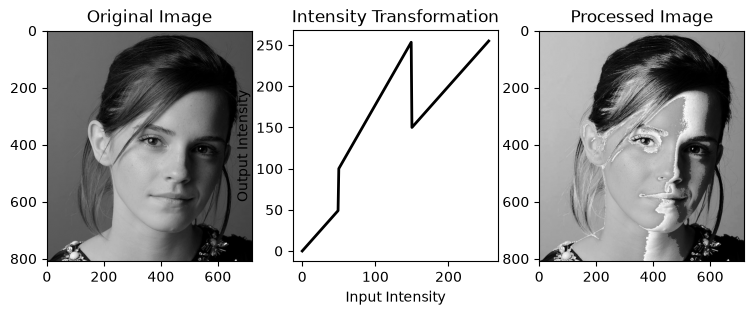

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

def intensity_transformation(im, breakpoints):
    input_values = breakpoints[:, 0]
    output_values = breakpoints[:, 1]
    transformed_im = np.interp(im.flatten(), input_values, output_values)
    return transformed_im.reshape(im.shape)

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],   
    [150, 255],
    [150, 150],
    [255, 255]
], dtype=np.uint8)

x = np.arange(256, dtype=np.uint8)
y = intensity_transformation(x, breakpoints)
im = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found. Please check the path."
processed_im = intensity_transformation(im, breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Image')

ax[1].plot(x, y, 'black', linewidth=2)
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_title('Intensity Transformation')

ax[2].imshow(processed_im, cmap='gray')
ax[2].set_title('Processed Image')

plt.show()


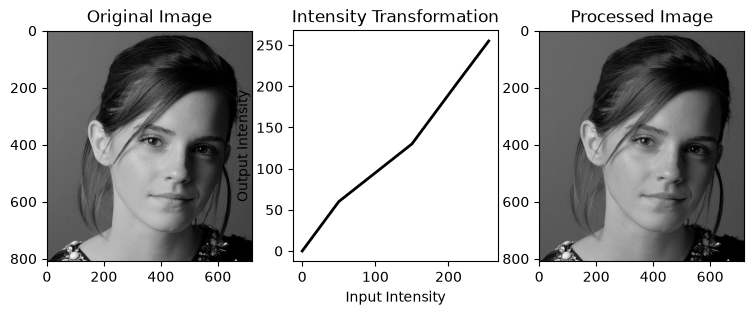

In [29]:
breakpoints = np.array([
    [0, 0], 
    [50, 60], 
    [150, 130], 
    [200, 190], 
    [255, 255]
], dtype=np.uint8)

x = np.arange(256, dtype=np.uint8)
y = intensity_transformation(x, breakpoints)
im = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)
processed_im = intensity_transformation(im, breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Image')

ax[1].plot(x, y, 'black', linewidth=2)
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_title('Intensity Transformation')

ax[2].imshow(processed_im, cmap='gray')
ax[2].set_title('Processed Image')

plt.show()

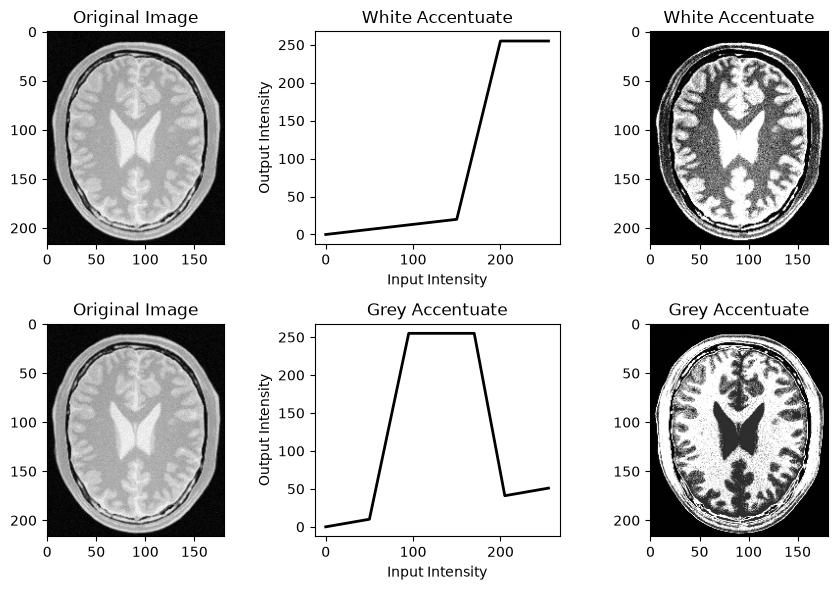

In [93]:
im = cv.imread('images/q2.jpeg', cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found. Please check the path."

# White Accentuate
breakpoints_1 = np.array([
    [0, 0], 
    [150, 20],
    [200, 255],
    [255, 255]
], dtype=np.uint8)

y_1 = intensity_transformation(x, breakpoints_1)
processed_im = intensity_transformation(im, breakpoints_1)

# Grey Accentuate
breakpoints_2 = np.array([
    [0, 0], 
    [50, 10], 
    [95, 255], 
    [170, 255],
    [205, 41],
    [255, 51]
], dtype=np.uint8)

y_2 = intensity_transformation(x, breakpoints_2)
processed_im_2 = intensity_transformation(im, breakpoints_2)

fig, ax = plt.subplots(2, 3, figsize=(9, 6))

ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].plot(x, y_1, 'black', linewidth=2)
ax[0, 1].set_xlabel('Input Intensity')
ax[0, 1].set_ylabel('Output Intensity')
ax[0, 1].set_title('White Accentuate')
ax[0, 2].imshow(processed_im, cmap='gray')
ax[0, 2].set_title('White Accentuate')

ax[1, 0].imshow(im, cmap='gray')
ax[1, 0].set_title('Original Image')
ax[1, 1].plot(x, y_2, 'black', linewidth=2)
ax[1, 1].set_xlabel('Input Intensity')
ax[1, 1].set_ylabel('Output Intensity')
ax[1, 1].set_title('Grey Accentuate')
ax[1, 2].imshow(processed_im_2, cmap='gray')
ax[1, 2].set_title('Grey Accentuate')

plt.tight_layout()
plt.show()

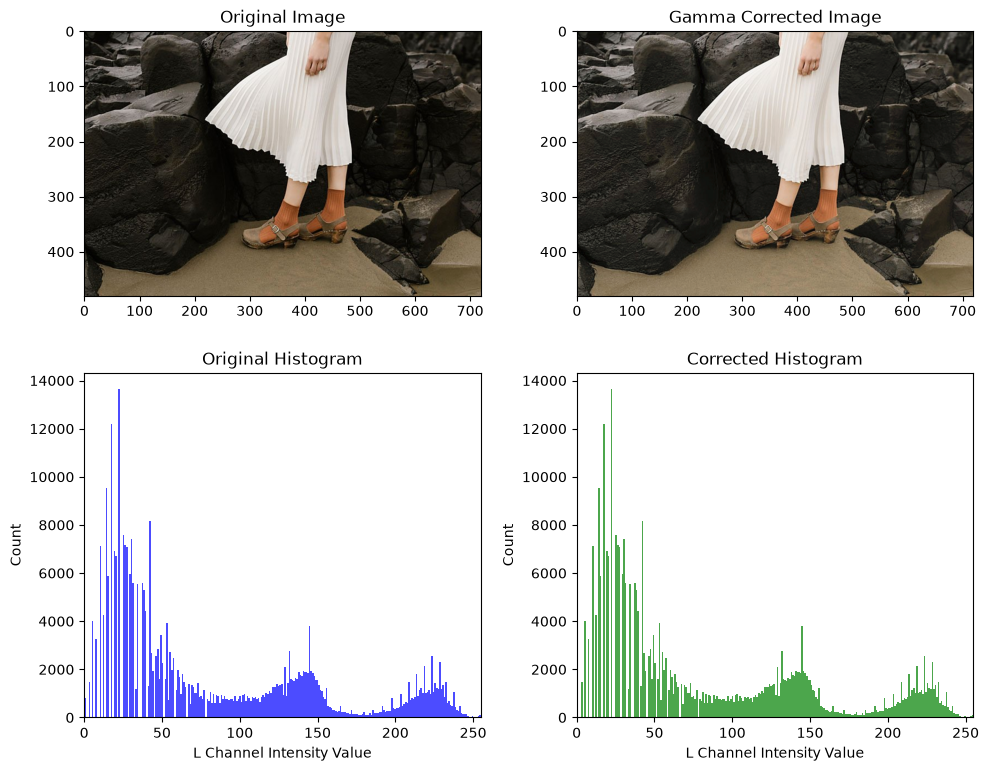

In [143]:
def gamma_correction(im, gamma): # gamma correction function in Lab color space
    im_lab = cv.cvtColor(im, cv.COLOR_BGR2Lab)
    l_channel, a_channel, b_channel = cv.split(im_lab)
    l_channel = np.power(l_channel / 255.0, gamma) * 255.0
    l_channel = np.clip(l_channel, 0, 255).astype(np.uint8)
    corrected_im_lab = cv.merge((l_channel, a_channel, b_channel))
    corrected_im = cv.cvtColor(corrected_im_lab, cv.COLOR_Lab2BGR)
    return corrected_im, l_channel

im = cv.imread('images/q3.jpeg')
assert im is not None, "Image not found. Please check the path."

# Apply gamma correction
gamma = 0.8
corrected_im, l_channel = gamma_correction(im, gamma)

# Display the original and corrected images alongside their histograms
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0, 0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0, 0].set_title('Original Image')

ax[0, 1].imshow(cv.cvtColor(corrected_im, cv.COLOR_BGR2RGB))
ax[0, 1].set_title('Gamma Corrected Image')

ax[1, 0].hist(l_channel.ravel(), bins=256, color='blue', alpha=0.7)
ax[1, 0].set_title('Original Histogram')
ax[1, 0].set_xlim(0, 255)
ax[1, 0].set_xlabel('L Channel Intensity Value')
ax[1, 0].set_ylabel('Count')

ax[1, 1].hist(l_channel.ravel(), bins=256, color='green', alpha=0.7)
ax[1, 1].set_title('Corrected Histogram')
ax[1, 1].set_xlim(0, 255)
ax[1, 1].set_xlabel('L Channel Intensity Value')
ax[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()